<a href="https://colab.research.google.com/github/youssouf2230/Analyse_des_sentiments_regroupement_thema/blob/main/Analyse_sentniment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import dataset

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/insaid2018/Term-3/master/Data/CaseStudy/Womens%20Clothing%20E-Commerce%20Reviews.csv',index_col = [0]) #removes unnamed:0


In [3]:
data.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


# Extraire les colonnes interresantes du dataset

In [31]:
data_copie = data[["Age","Review Text","Rating","Positive Feedback Count"]]

In [32]:
data_copie.head()

,Age,Review Text,Rating,Positive Feedback Count
0,33,Absolutely wonderful - silky and sexy and comf...,4,0
1,34,Love this dress! it's sooo pretty. i happene...,5,4
2,60,I had such high hopes for this dress and reall...,3,0
3,50,"I love, love, love this jumpsuit. it's fun, fl...",5,0
4,47,This shirt is very flattering to all due to th...,5,6


# Compte number de valeur null dans dataset

In [10]:
data_copie.isnull().sum()

,0
Age,0
Review Text,845
Rating,0
Positive Feedback Count,0


# Suppprimer les lignes qui contiennent des valeurs null

In [33]:
data_copie = data_copie.dropna()

In [12]:
data_copie.isnull().sum()

,0
Age,0
Review Text,0
Rating,0
Positive Feedback Count,0


In [14]:
data_copie.head()

,Age,Review Text,Rating,Positive Feedback Count
0,33,Absolutely wonderful - silky and sexy and comf...,4,0
1,34,Love this dress! it's sooo pretty. i happene...,5,4
2,60,I had such high hopes for this dress and reall...,3,0
3,50,"I love, love, love this jumpsuit. it's fun, fl...",5,0
4,47,This shirt is very flattering to all due to th...,5,6


# Prétraitement du dataset

In [15]:
# import sentimentAnalyzer
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [16]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [34]:
sia = SentimentIntensityAnalyzer()

In [35]:
# aplliquer sur dataset et stock chaque score dans score
data_copie['score'] = data_copie['Review Text'].apply(lambda review: sia.polarity_scores(str(review))['compound'])

In [36]:
data_copie.head()

,Age,Review Text,Rating,Positive Feedback Count,score
0,33,Absolutely wonderful - silky and sexy and comf...,4,0,0.8932
1,34,Love this dress! it's sooo pretty. i happene...,5,4,0.9729
2,60,I had such high hopes for this dress and reall...,3,0,0.9427
3,50,"I love, love, love this jumpsuit. it's fun, fl...",5,0,0.5727
4,47,This shirt is very flattering to all due to th...,5,6,0.9291


In [37]:
# supprimer colonne review text
data_copie = data_copie.drop('Review Text',axis = 1)

In [38]:
data_copie.head()

,Age,Rating,Positive Feedback Count,score
0,33,4,0,0.8932
1,34,5,4,0.9729
2,60,3,0,0.9427
3,50,5,0,0.5727
4,47,5,6,0.9291


In [39]:
data_copie['score'].min()

-0.9562

In [40]:
# chercher min score et ajouter dans abs de min score dans chaque score pour éviter des valeur nég
min_score = abs(data_copie['score'].min())
min_score

0.9562

In [41]:
data_copie['score'] = data_copie['score'].apply(lambda score: score + min_score)

In [42]:
abs(data_copie['score'].min())

0.0

In [43]:
# ajouter 1 à chque valeur pour s'assurer que toutess les valeurs sont positives afin d'eviter log(0)
columns_names = ["Age","Rating","Positive Feedback Count","score"]
for column in columns_names:
  data_copie[column] = data_copie[column].apply(lambda value: value + 1)

In [44]:
abs(data_copie['score'].min())

1.0

In [45]:
# fonction d'afficher hsitogramme
import matplotlib.pyplot as plt
def Hist(string):
  plt.hist(data_copie[string])
  plt.title(string)
  plt.show()


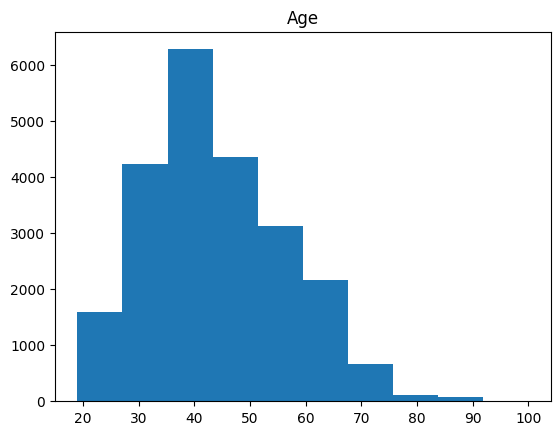

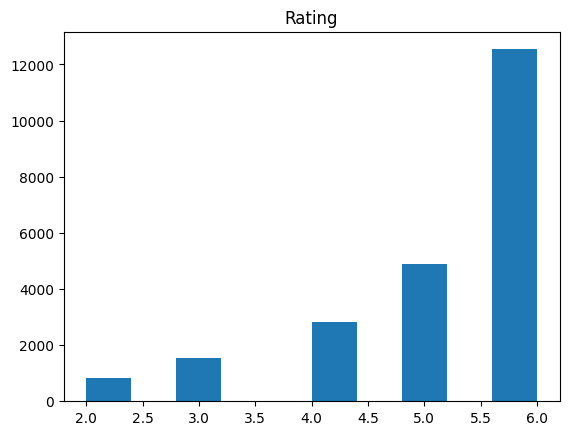

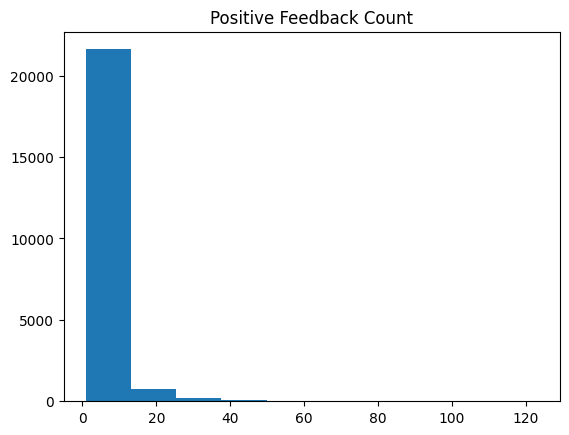

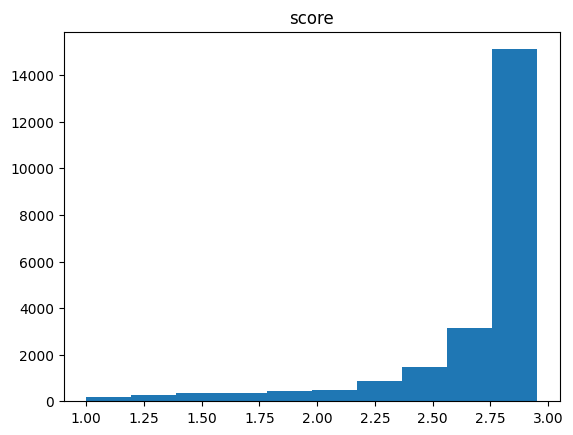

In [46]:
# afficher tous les his
for column in columns_names:
  Hist(column)

In [47]:
# appliquer log dans chaque valeur
import numpy as np
for column in columns_names:
  data_copie[column] = data_copie[column].apply(lambda value: np.log(value))

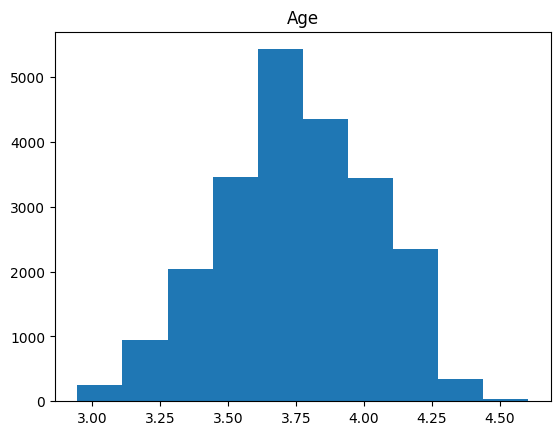

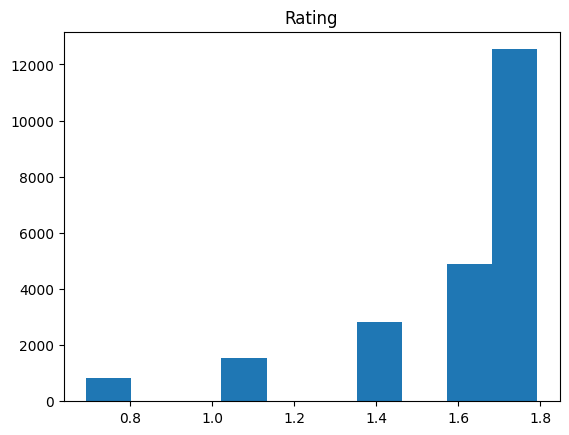

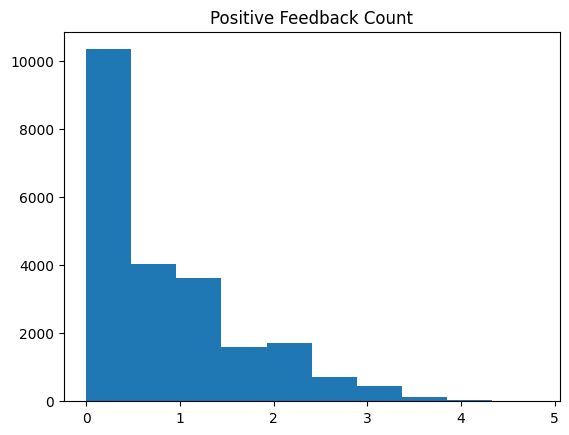

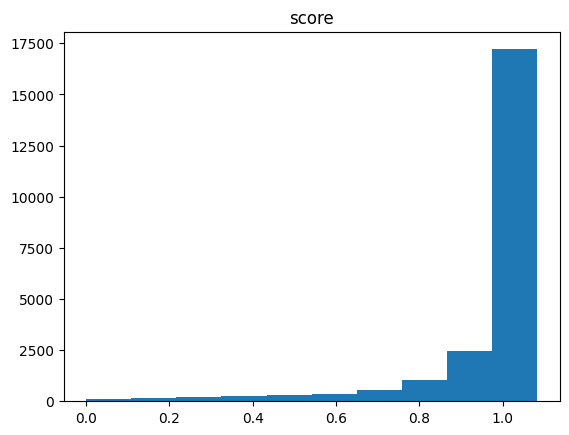

In [48]:
# re afficher les hist
for column in columns_names:
  Hist(column)

D'après les fig ci dessus les échelles sont reduites

In [53]:
data_copie.head()

,Age,Rating,Positive Feedback Count,score
0,3.526361,1.609438,0.000000,1.047108
1,3.555348,1.791759,1.609438,1.074695
2,4.110874,1.386294,0.000000,1.064331
3,3.931826,1.791759,0.000000,0.927784
4,3.871201,1.791759,1.945910,1.059629


In [54]:
import numpy as np
from scipy import stats
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Colonnes utilisées pour le clustering
scores_mod = data_copie[['Age', 'Rating', 'Positive Feedback Count', 'score']]

# Standardisation (Z-score) — permet de traiter même les distributions asymétriques
scores_std = stats.zscore(scores_mod)
scores_std = np.array(scores_std)

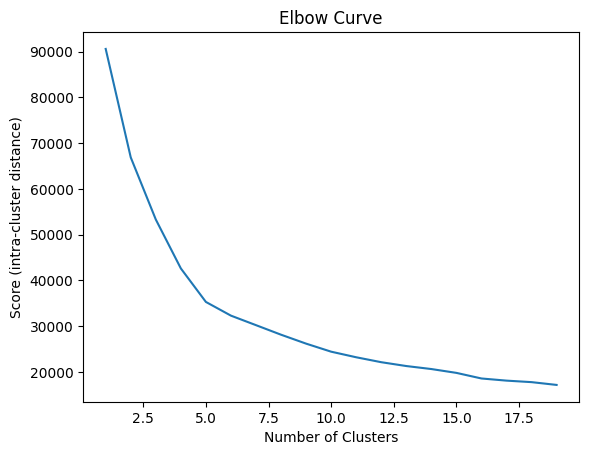

In [55]:
number_of_clusters = range(1, 20)
kmeans_list = [KMeans(n_clusters=i, max_iter=1000, random_state=42) for i in number_of_clusters]
score_list = [-1 * kmeans_list[i].fit(scores_std).score(scores_std) for i in range(len(kmeans_list))]

plt.plot(number_of_clusters, score_list)
plt.xlabel('Number of Clusters')
plt.ylabel('Score (intra-cluster distance)')
plt.title('Elbow Curve')
plt.show()

In [56]:
# Supposons que le coude indique 6 clusters
kmeans_test = KMeans(n_clusters=6, max_iter=10000, random_state=42)
kmeans_test.fit(scores_std)

# Ajouter les labels au DataFrame original
data_copie['labels'] = kmeans_test.labels_

# Afficher les centres de clusters
print("Centres de clusters :")
print(kmeans_test.cluster_centers_)

Centres de clusters :
[[-0.00477234 -1.27972383  0.09112137 -3.30486576]
 [-0.90845777  0.31063752 -0.63387925  0.26324258]
 [ 0.77807063  0.35158251 -0.63657773  0.25427133]
 [ 0.96829942  0.31369682  1.11967369  0.27400603]
 [-0.60364836  0.24191421  1.16924181  0.27926539]
 [-0.01805502 -2.32663289  0.13546392 -0.29259095]]


In [57]:
cluster_size = data_copie.groupby('labels').size().reset_index()
cluster_size.columns = ['labels', 'number_of_points']
cluster_size['percentage'] = cluster_size['number_of_points'] / cluster_size['number_of_points'].sum()

print(cluster_size)

   labels  number_of_points  percentage
0       0              1395    0.061614
1       1              6399    0.282629
2       2              6277    0.277240
3       3              3212    0.141867
4       4              3522    0.155559
5       5              1836    0.081092


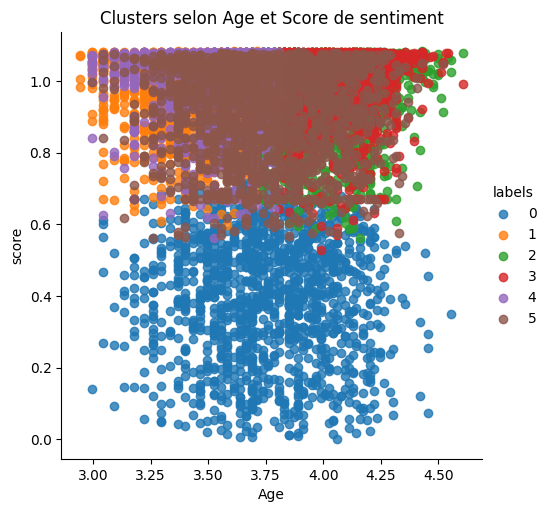

In [58]:
import seaborn as sns

sns.lmplot(x='Age', y='score', data=data_copie, hue='labels', fit_reg=False)
plt.title('Clusters selon Age et Score de sentiment')
plt.show()

d'après cette fig de cluster on voit que notre regroupement n'est pas trop bonne. Nous allons essayer de rendre age et score à la distribution normale

In [67]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [68]:
# Ajouter +1 si nécessaire pour que toutes valeurs >0
age_bc, lambda_age = stats.boxcox(data_copie['Age'] + 1)
score_bc, lambda_score = stats.boxcox(data_copie['score'] + abs(data_copie['score'].min()) + 1)

data_copie['Age_trans'] = age_bc
data_copie['score_trans'] = score_bc

In [69]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
data_copie[['Age_trans', 'score_trans']] = pt.fit_transform(
    data_copie[['Age','score']]
)


In [70]:
features = ['Age_trans','Rating','Positive Feedback Count','score_trans']
scaler = StandardScaler()
X_std = scaler.fit_transform(data_copie[features])


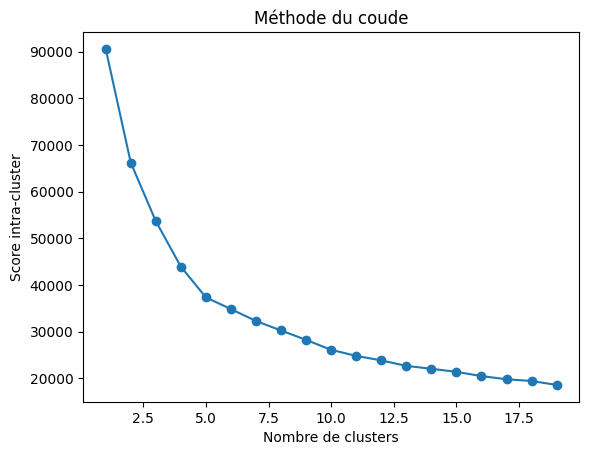

In [83]:
import matplotlib.pyplot as plt

number_of_clusters = range(1, 20)
scores = []

for k in number_of_clusters:
    km = KMeans(n_clusters=k, max_iter=1000, random_state=42)
    km.fit(X_std)
    scores.append(-km.score(X_std))

plt.plot(number_of_clusters, scores, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Score intra-cluster")
plt.title("Méthode du coude")
plt.show()


In [72]:
kmeans_final = KMeans(n_clusters=4, max_iter=10000, random_state=42)
kmeans_final.fit(X_std)
data_copie['label'] = kmeans_final.labels_
print(kmeans_final.cluster_centers_)


[[-0.01084118 -2.46640575  0.14266019 -1.13917294]
 [ 0.14365468  0.24933087  1.58233869  0.39861741]
 [-1.41549602  0.31997198 -0.31249612  0.44268329]
 [ 1.21187348  0.39689478 -0.32315058  0.45134985]
 [-0.16559968  0.39740691 -0.57663208  0.52855454]
 [-0.02074758 -0.12767111 -0.18261235 -1.52790835]]


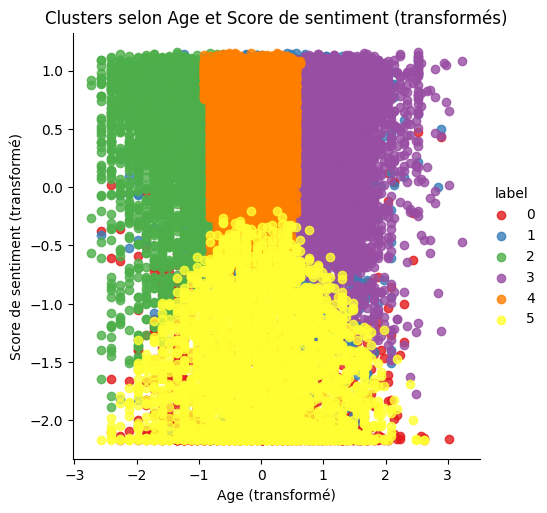

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Affichage des clusters selon les variables transformées
sns.lmplot(
    x='Age_trans',
    y='score_trans',
    data=data_copie,
    hue='label',   # label des clusters
    fit_reg=False,
    palette='Set1'
)
plt.title('Clusters selon Age et Score de sentiment (transformés)')
plt.xlabel('Age (transformé)')
plt.ylabel('Score de sentiment (transformé)')
plt.show()


| Cluster | Âge                | Rating              | Positive Feedback Count     | Score de sentiment   | Interprétation                                              |
| ------- | ------------------ | ------------------- | --------------------------- | -------------------- | ----------------------------------------------------------- |
| 0       | -0.01 (très jeune) | -2.47 (très faible) | 0.14 (neutre)               | -1.14 (très négatif) | **Jeune avec avis très négatifs et peu de notes positives** |
| 1       | 0.14 (moyen)       | 0.25 (moyen)        | 1.58 (beaucoup de feedback) | 0.40 (positif)       | **Âge moyen, beaucoup de feedbacks et avis positifs**       |
| 2       | -1.42 (très jeune) | 0.32 (moyen)        | -0.31 (peu de feedback)     | 0.44 (positif)       | **Très jeune, peu de feedback, avis légèrement positifs**   |
| 3       | 1.21 (plus âgé)    | 0.40 (moyen)        | -0.32 (peu de feedback)     | 0.45 (positif)       | **Plus âgé, peu de feedback, avis positifs**                |
| 4       | -0.17 (jeune)      | 0.40 (moyen)        | -0.58 (peu de feedback)     | 0.53 (positif)       | **Jeune, peu de feedback, avis positifs modérés**           |
| 5       | -0.02 (jeune)      | -0.13 (faible)      | -0.18 (faible)              | -1.53 (très négatif) | **Jeune, peu de feedback, avis très négatifs**              |


In [82]:
# Nouvelle donnée test
new_review = {
    'Age': 28,
    'Review Text': "This dress is amazing! I absolutely love it."
}

# Calcul du score de sentiment (VADER)
sent_score = sia.polarity_scores(new_review['Review Text'])['compound']

# Préparer le vecteur avec les colonnes dans le bon ordre
# Ici on suppose les colonnes sont ['Age', 'Rating', 'Positive Feedback Count', 'score']
# Comme c'est un test, on peut mettre Rating et Feedback = moyenne ou 1
X_new = np.array([[new_review['Age'], 1.0, 1.0, sent_score]])

# Standardisation avec stats d'entraînement
mean_train = scores_mod.mean().values
std_train = scores_mod.std().values
X_new_std = (X_new - mean_train) / std_train

# Prédiction du cluster
cluster_pred = kmeans_test.predict(X_new_std)
print(f"La nouvelle review est assignée au cluster : {cluster_pred[0]}")


La nouvelle review est assignée au cluster : 3
